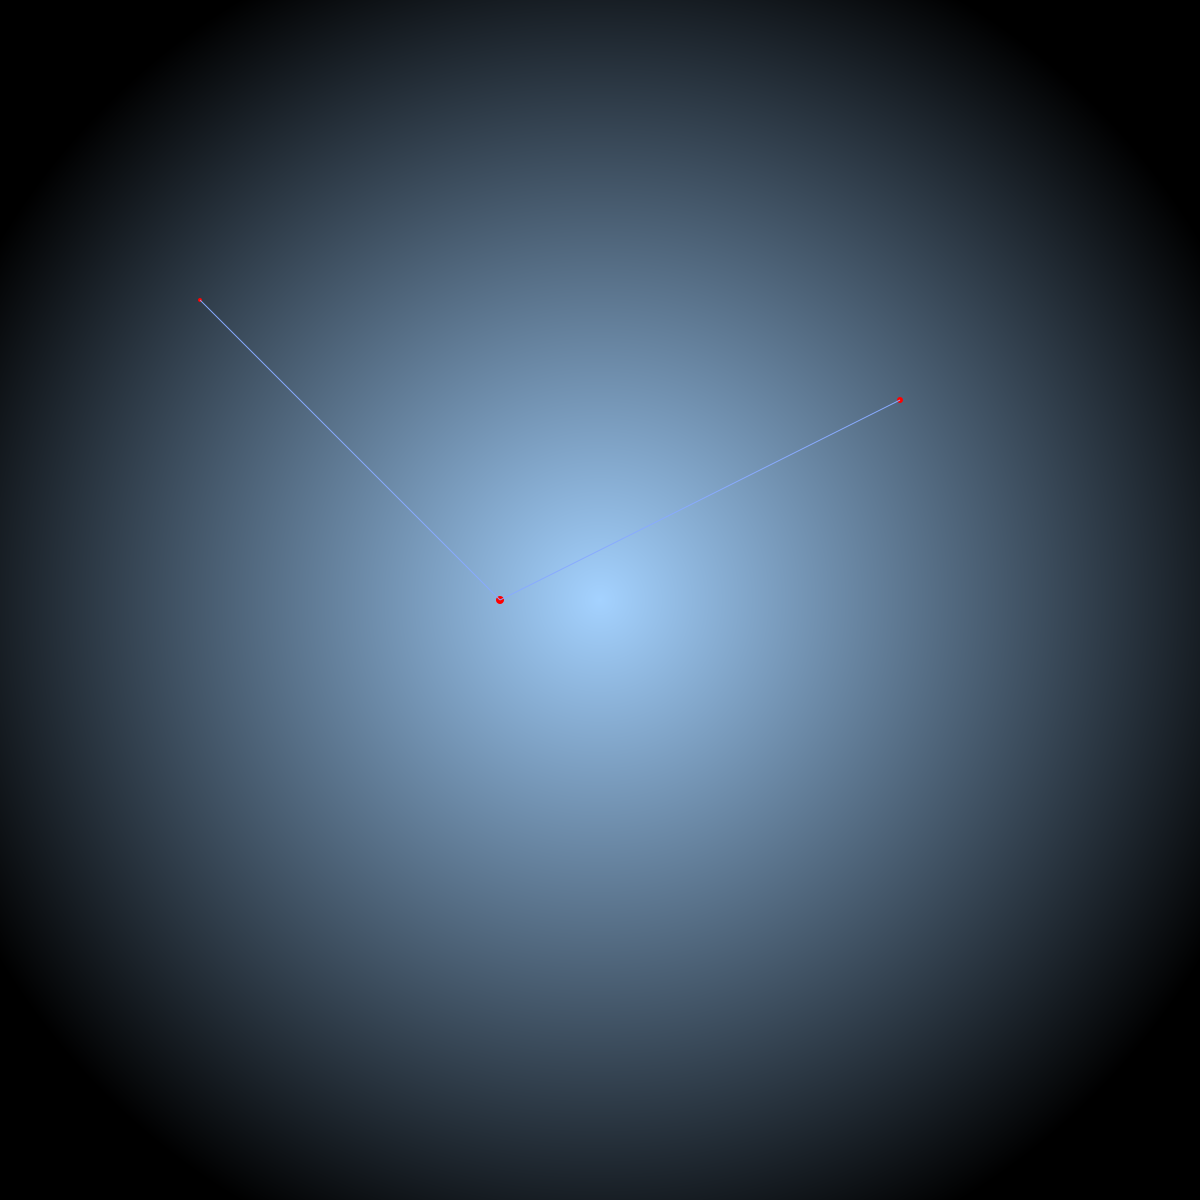

In [1]:
import drawsvg as draw

d = draw.Drawing(1200, 1200)

# Background gradient
grad = draw.RadialGradient(600, 600, 700)
grad.add_stop(0, "#A4D2FF")
grad.add_stop(1, '#000000')

d.append(draw.Rectangle(
    0, 0, 1200, 1200,
    fill=grad
))

# Star positions
stars = [
    (200, 300, 2),
    (500, 600, 4),
    (900, 400, 3),
]

# Draw stars
for x, y, r in stars:
    d.append(draw.Circle(
        x, y, r,
        fill='red'
    ))

# Constellation lines
lines = [
    ((200, 300), (500, 600)),
    ((500, 600), (900, 400)),
]

for (x1, y1), (x2, y2) in lines:
    d.append(draw.Line(
        x1, y1,
        x2, y2,
        stroke='#88aaff',
        stroke_width=1
    ))

d.save_svg('chart.svg')
d

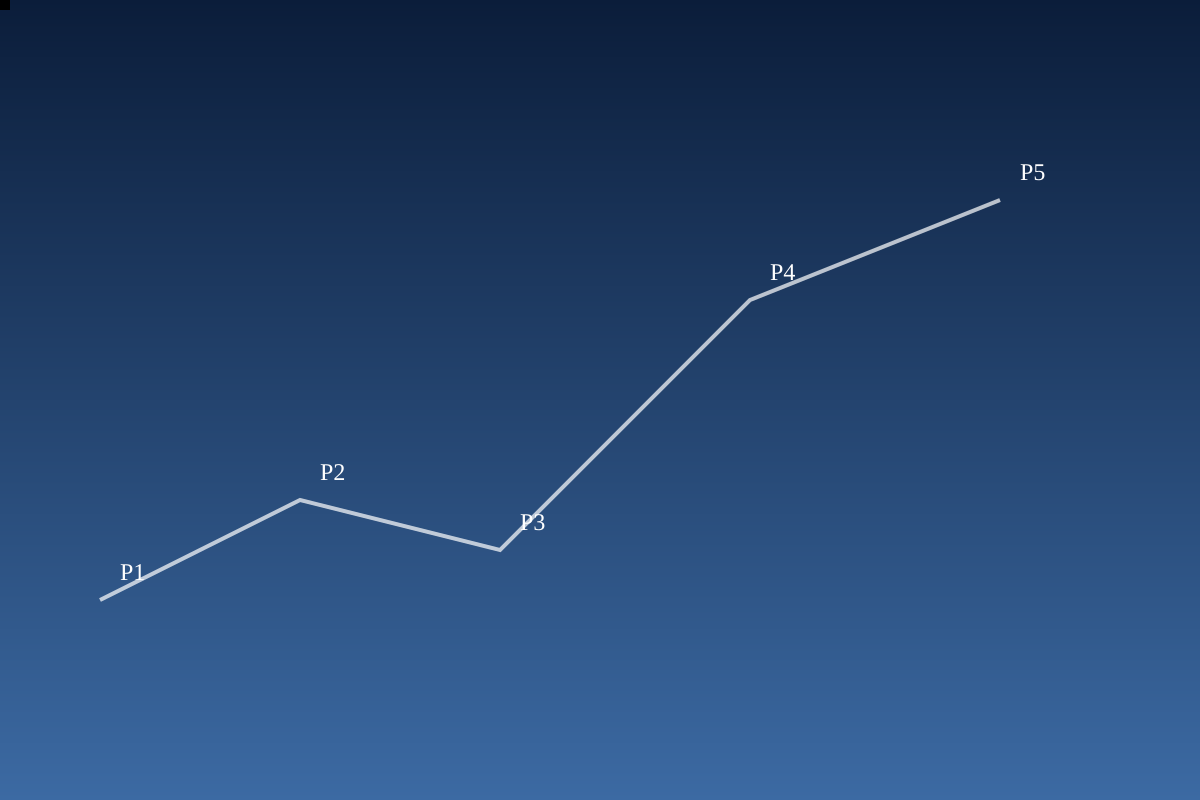

In [18]:
import drawsvg as draw
import xml.etree.ElementTree as ET

# ------------------------------------------------------------
# Load SVG and extract layers
# ------------------------------------------------------------

svg_file = 'rect1.svg'
tree = ET.parse(svg_file)
root = tree.getroot()

ns = {'svg': 'http://www.w3.org/2000/svg'}

layers = {}

for g in root.findall('svg:g', ns):
    layer_id = g.attrib.get('id')

    group = draw.Group(id=layer_id)

    # Convert children manually (simple shapes only here)
    for elem in g:
        tag = elem.tag.split('}')[-1]

        if tag == 'rect':
            group.append(draw.Rectangle(
                float(elem.attrib['x']),
                float(elem.attrib['y']),
                float(elem.attrib['width']),
                float(elem.attrib['height']),
                fill=elem.attrib.get('style', '#000000')
            ))

        elif tag == 'circle':
            group.append(draw.Circle(
                float(elem.attrib['cx']),
                float(elem.attrib['cy']),
                float(elem.attrib['r']),
                fill=elem.attrib.get('style', '#000000')
            ))

        elif tag == 'path':
            group.append(draw.Path(
                d=elem.attrib['d'],
                fill=elem.attrib.get('style', '#000000')
            ))

    layers[layer_id] = group

# ------------------------------------------------------------
# Drawing
# ------------------------------------------------------------

W, H = 1200, 800
d = draw.Drawing(W, H)

# Background gradient
grad = draw.LinearGradient(0, 0, 0, H)
grad.add_stop(0, '#0b1d3a')
grad.add_stop(1, '#3c6aa3')

d.append(draw.Rectangle(0, 0, W, H, fill=grad))

# ------------------------------------------------------------
# Add layers to defs (THIS is correct drawsvg usage)
# ------------------------------------------------------------

for layer in layers.values():
    d.append(layer)  # IMPORTANT: groups with id go into defs automatically

# ------------------------------------------------------------
# Marker helper (layer toggle supported)
# ------------------------------------------------------------

def add_marker(x, y, scale=5, layers=('layer1', 'layer2')):
    for layer in layers:
        d.append(draw.Use(
            f'#{layer}',
            x=x,
            y=y,
            transform=f'scale({scale})'
        ))

# ------------------------------------------------------------
# Example points
# ------------------------------------------------------------

points = [
    (100, 600),
    (300, 500),
    (500, 550),
    (750, 300),
    (1000, 200),
]

# Connecting line
path = draw.Path(stroke='white', stroke_width=4, fill='none', opacity=0.7)
path.M(*points[0])
for p in points[1:]:
    path.L(*p)
d.append(path)

# ------------------------------------------------------------
# Markers (layer3 = highlight toggle)
# ------------------------------------------------------------

add_marker(100, 600, layers=('layer1', 'layer2'))
add_marker(300, 500, layers=('layer1', 'layer2', 'layer3'))
add_marker(500, 550, layers=('layer1', 'layer2'))
add_marker(750, 300, layers=('layer1', 'layer2', 'layer3'))
add_marker(1000, 200, layers=('layer1', 'layer2'))

# Labels
for i, (x, y) in enumerate(points):
    d.append(draw.Text(f'P{i+1}', 24, x+20, y-20, fill='white'))

# Save
d.save_svg('example.svg')
d

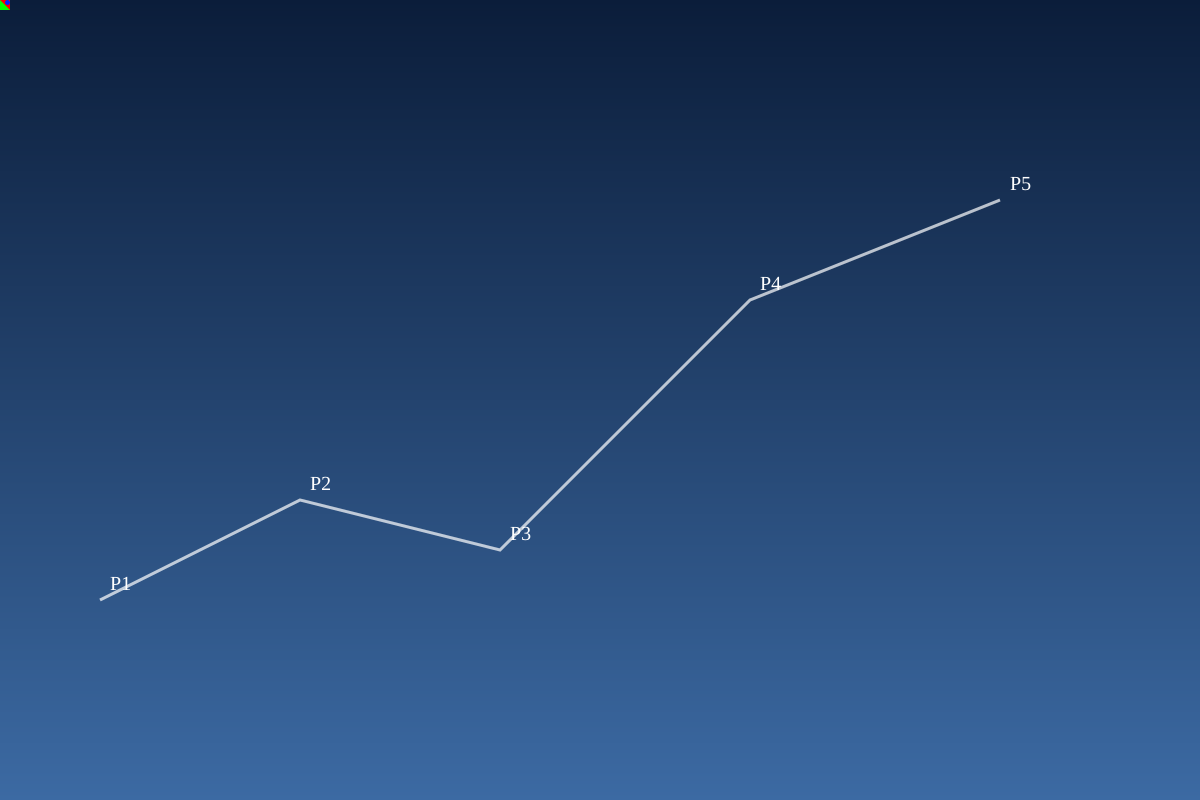

In [21]:
import drawsvg as draw
import xml.etree.ElementTree as ET

# ------------------------------------------------------------
# Parse SVG layers
# ------------------------------------------------------------

svg_file = "rect1.svg"
tree = ET.parse(svg_file)
root = tree.getroot()

ns = {'svg': 'http://www.w3.org/2000/svg'}

layers = {}

for g in root.findall('svg:g', ns):
    layer_id = g.attrib['id']

    group = draw.Group(id=layer_id)

    for elem in g:
        tag = elem.tag.split('}')[-1]

        style = elem.attrib.get('style', '')

        # VERY IMPORTANT: extract fill correctly
        fill = None
        if "fill:" in style:
            fill = style.split("fill:")[1].split(";")[0]

        if tag == "rect":
            group.append(draw.Rectangle(
                float(elem.attrib['x']),
                float(elem.attrib['y']),
                float(elem.attrib['width']),
                float(elem.attrib['height']),
                fill=fill
            ))

        elif tag == "circle":
            group.append(draw.Circle(
                float(elem.attrib['cx']),
                float(elem.attrib['cy']),
                float(elem.attrib['r']),
                fill=fill
            ))

        elif tag == "path":
            group.append(draw.Path(
                d=elem.attrib['d'],
                fill=fill
            ))

    layers[layer_id] = group

# ------------------------------------------------------------
# Drawing
# ------------------------------------------------------------

W, H = 1200, 800
d = draw.Drawing(W, H)

# background gradient
grad = draw.LinearGradient(0, 0, 0, H)
grad.add_stop(0, "#0b1d3a")
grad.add_stop(1, "#3c6aa3")

d.append(draw.Rectangle(0, 0, W, H, fill=grad))

# ------------------------------------------------------------
# IMPORTANT: register groups (this is enough in drawsvg)
# ------------------------------------------------------------

for g in layers.values():
    d.append(g)

# ------------------------------------------------------------
# Marker system using GROUP REFERENCES (no defs needed)
# ------------------------------------------------------------

def add_marker(x, y, layers_to_use, scale=5):
    for layer_id in layers_to_use:
        d.append(draw.Use(
            f"#{layer_id}",
            x=x,
            y=y,
            transform=f"scale({scale})"
        ))

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

points = [
    (100, 600),
    (300, 500),
    (500, 550),
    (750, 300),
    (1000, 200),
]

# lines between markers
path = draw.Path(stroke="white", stroke_width=3, fill="none", opacity=0.7)
path.M(*points[0])
for p in points[1:]:
    path.L(*p)

d.append(path)

# ------------------------------------------------------------
# Markers (layer3 = highlight toggle)
# ------------------------------------------------------------

add_marker(100, 600, ("layer1", "layer2"))
add_marker(300, 500, ("layer1", "layer2", "layer3"))
add_marker(500, 550, ("layer1", "layer2"))
add_marker(750, 300, ("layer1", "layer2", "layer3"))
add_marker(1000, 200, ("layer1", "layer2"))

# labels
for i, (x, y) in enumerate(points):
    d.append(draw.Text(f"P{i+1}", 20, x+10, y-10, fill="white"))

d.save_svg("example.svg")
d

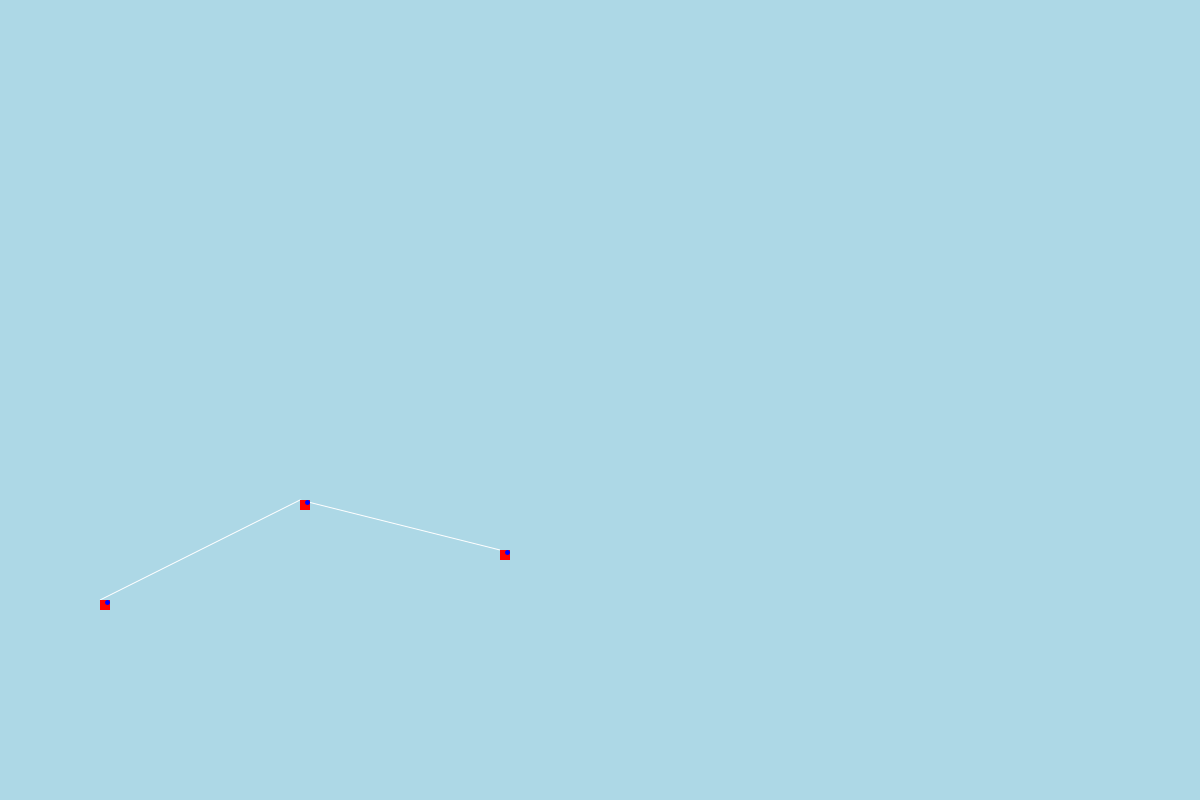

In [23]:
import svgwrite

dwg = svgwrite.Drawing("test.svg", size=(1200, 800))

# defs + symbol
symbol = dwg.symbol(id="marker", viewBox="0 0 10 10")
symbol.add(dwg.rect((0, 0), (10, 10), fill="red"))
symbol.add(dwg.circle(center=(7.5, 2.5), r=2.5, fill="blue"))
dwg.defs.add(symbol)

# background
dwg.add(dwg.rect((0, 0), (1200, 800), fill="lightblue"))

# line
points = [(100, 600), (300, 500), (500, 550)]
dwg.add(dwg.polyline(points, stroke="white", fill="none"))

# markers
for x, y in points:
    dwg.add(dwg.use("#marker", insert=(x, y), size=(10, 10)))

dwg.save()
dwg

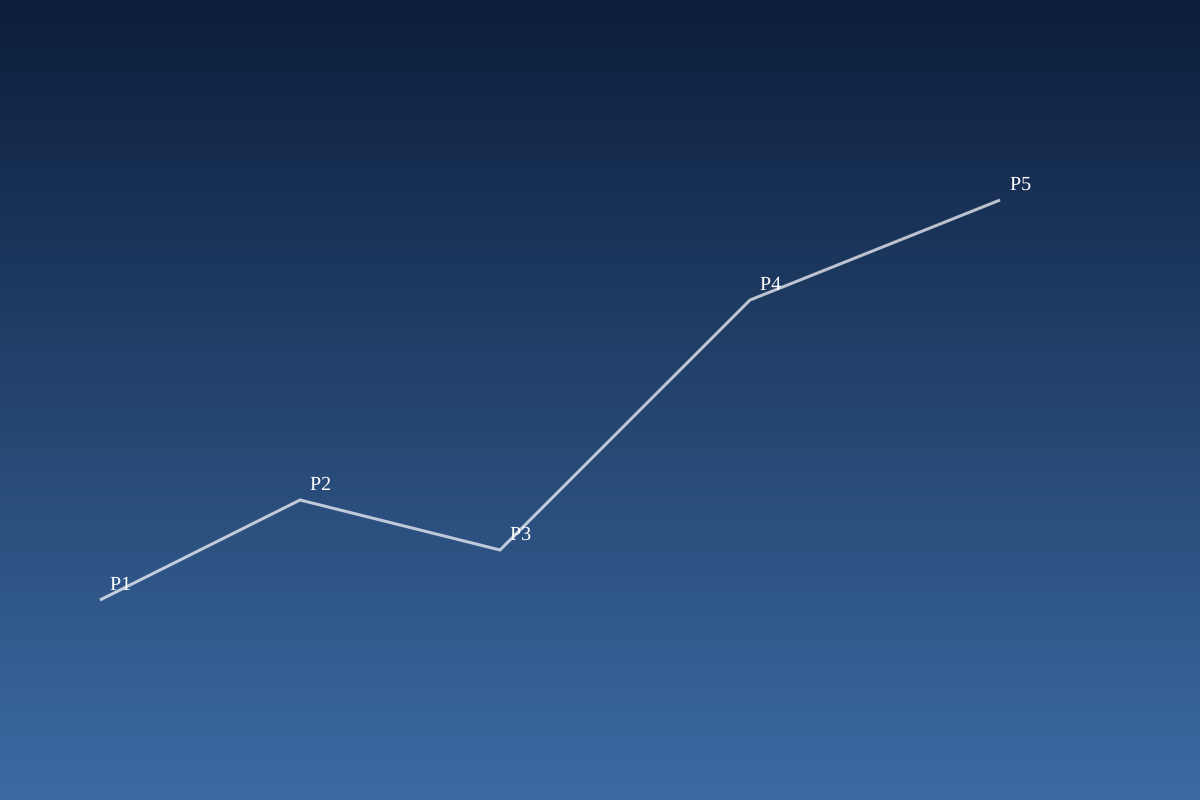

In [37]:
import svgwrite
import xml.etree.ElementTree as ET

# ------------------------------------------------------------
# Load Inkscape SVG and extract layers
# ------------------------------------------------------------

svg_file = "rect1.svg"

tree = ET.parse(svg_file)
root = tree.getroot()

ns = {"svg": "http://www.w3.org/2000/svg"}

layers = {}

for g in root.findall("svg:g", ns):
    layer_id = g.attrib["id"]

    # store raw group XML content
    layers[layer_id] = g

# ------------------------------------------------------------
# Create drawing
# ------------------------------------------------------------

W, H = 1200, 800
dwg = svgwrite.Drawing("example.svg", size=(W, H))

# ------------------------------------------------------------
# Background gradient
# ------------------------------------------------------------

grad = dwg.linearGradient(start=(0, 0), end=(0, 1), id="bggrad")
grad.add_stop_color(0, "#0b1d3a")
grad.add_stop_color(1, "#3c6aa3")
dwg.defs.add(grad)

dwg.add(dwg.rect(insert=(0, 0), size=(W, H), fill="url(#bggrad)"))

# ------------------------------------------------------------
# Convert each layer into a SYMBOL (THIS is the key fix)
# ------------------------------------------------------------

def convert_layer_to_symbol(layer_elem, symbol_id):

    # ------------------------------------------------------------
    # 1. read original bounds (assumes 0..10 if Inkscape)
    # ------------------------------------------------------------

    min_x, min_y = 0, 0
    max_x, max_y = 10, 10

    cx = (min_x + max_x) / 2
    cy = (min_y + max_y) / 2

    scale = 2.0 / max(max_x - min_x, max_y - min_y)

    # ------------------------------------------------------------
    # 2. create normalized symbol
    # ------------------------------------------------------------

    symbol = dwg.symbol(id=symbol_id, viewBox="-1 -1 2 2")

    for child in layer_elem:
        tag = child.tag.split("}")[-1]
        style = child.attrib.get("style", "")

        fill = None
        if "fill:" in style:
            fill = style.split("fill:")[1].split(";")[0]

        # --------------------------------------------------------
        # RECT
        # --------------------------------------------------------
        if tag == "rect":
            x = float(child.attrib["x"])
            y = float(child.attrib["y"])
            w = float(child.attrib["width"])
            h = float(child.attrib["height"])

            # normalize center
            x = (x - cx) * scale
            y = (y - cy) * scale
            w = w * scale
            h = h * scale

            symbol.add(dwg.rect((x, y), (w, h), fill=fill))

        # --------------------------------------------------------
        # CIRCLE
        # --------------------------------------------------------
        elif tag == "circle":
            x = float(child.attrib["cx"])
            y = float(child.attrib["cy"])
            r = float(child.attrib["r"])

            x = (x - cx) * scale
            y = (y - cy) * scale
            r = r * scale

            symbol.add(dwg.circle((x, y), r, fill=fill))

        # --------------------------------------------------------
        # PATH (kept raw but scaled via transform)
        # --------------------------------------------------------
        elif tag == "path":
            symbol.add(
                dwg.path(
                    d=child.attrib["d"],
                    fill=fill,
                    transform=f"translate({-cx}, {-cy}) scale({scale})"
                )
            )

    dwg.defs.add(symbol)

# create symbols
for layer_id, elem in layers.items():
    convert_layer_to_symbol(elem, layer_id)

# ------------------------------------------------------------
# Optional: combine layers into marker presets
# ------------------------------------------------------------

# base marker
dwg.defs.add(dwg.symbol(
    id="marker_base",
    viewBox="-1 -1 2 2"
))

# highlight marker (includes layer3)
dwg.defs.add(dwg.symbol(
    id="marker_highlight",
    viewBox="-1 -1 2 2"
))

# NOTE:
# svgwrite does not auto-compose symbols,
# so we instead just reuse layers directly below.

# ------------------------------------------------------------
# Points
# ------------------------------------------------------------

points = [
    (100, 600),
    (300, 500),
    (500, 550),
    (750, 300),
    (1000, 200),
]

# ------------------------------------------------------------
# Connecting line
# ------------------------------------------------------------

dwg.add(dwg.polyline(
    points,
    stroke="white",
    fill="none",
    stroke_width=3,
    opacity=0.7
))

# ------------------------------------------------------------
# Marker drawing function
# ------------------------------------------------------------

def add_marker(x, y, highlight=False, scale=5):

    # base layers
    for layer in ["layer1", "layer2"]:
        dwg.add(dwg.use(
            f"#{layer}",
            insert=(x, y),
            transform=f"scale({scale})"
        ))

    # optional highlight layer
    if highlight:
        dwg.add(dwg.use(
            "#layer3",
            insert=(x, y),
            transform=f"scale({scale})"
        ))

# ------------------------------------------------------------
# Render markers
# ------------------------------------------------------------

add_marker(100, 600)
add_marker(300, 500, highlight=True)
add_marker(500, 550)
add_marker(750, 300, highlight=True)
add_marker(1000, 200)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

for i, (x, y) in enumerate(points):
    dwg.add(dwg.text(
        f"P{i+1}",
        insert=(x + 10, y - 10),
        fill="white",
        font_size="20px"
    ))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

dwg.save()
dwg

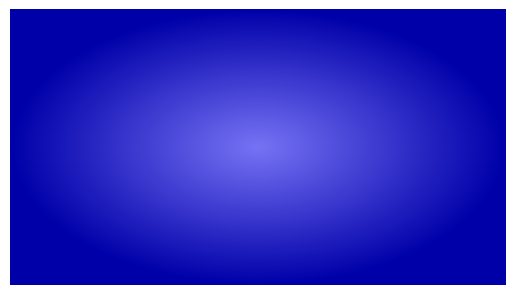

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    return np.array([int(hex_color[i:i+2], 16) for i in (0, 2, 4)]) / 255.0

fig, ax = plt.subplots()

w, h = 900, 500

# coordinate grid (centered)
y = np.linspace(-1, 1, h)[:, None]
x = np.linspace(-1, 1, w)[None, :]

# ellipse shape control (auto-fit to rectangle)
aspect = w / h
r = np.sqrt(x**2 + (y)**2)
r = np.clip(r, 0, 1)

# HEX colors
center_hex = "#7773F5"
edge_hex   = "#0000A9"

c1 = hex_to_rgb(center_hex)
c2 = hex_to_rgb(edge_hex)

# blend
img = (1 - r)[..., None] * c1 + r[..., None] * c2

ax.imshow(img, origin="lower")
ax.axis("off")
ax.set_aspect('equal')

plt.show()

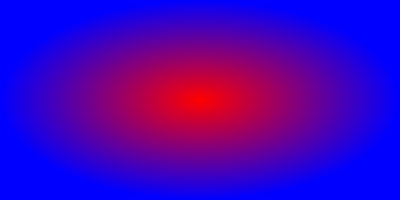

In [44]:
import svgwrite

dwg = svgwrite.Drawing("gradient.svg", size=("400px", "200px"))

grad = dwg.radialGradient()
grad.add_stop_color(0, "#ff0000")
grad.add_stop_color(1, "#0000ff")

dwg.defs.add(grad)

dwg.add(dwg.rect(insert=(0, 0), size=("400px", "200px"), fill=grad.get_paint_server()))

dwg.save()
dwg

# YAML importing example

In [59]:
import yaml

with open("card_formats.yaml", 'r') as file:
    data = yaml.safe_load(file)

# Now 'data' is a Python dictionary
print(data['tarot'])


{'height': 4.75, 'width': 2.75, 'pad': 0.25, 'text_x': 0.4, 'text_y': 3.6, 'box_width': 1.95, 'box_height': 0.8, 'max_font_scale': 3, 'round': {'box_style': "f'round, pad:0.0, rounding_size:0.2'", 'text_box_style': 'round, pad : 0.2, rounding_size:0.3', 'default_cardback_file': 'cardbacks/tarot_round.png'}, 'square': {'box_style': 'square, pad:0.0', 'text_box_style': 'round, pad : 0.2, rounding_size:0.05', 'default_cardback_file': 'cardbacks/tarot_square.png'}}


In [61]:
'round' in data['circle'].keys()

False

# SVG read multiple layers

In [42]:
from svgpathtools import svg2paths
from svgpath2mpl import parse_path
import numpy as np


def load_svg_path(file):
    _, attributes, *_ = svg2paths(file)
    base_path = parse_path(attributes[0]['d'])
    vertices = np.array(base_path.vertices)
    # Translate the path to be centered in 0 and scaled to 1
    offset = (vertices.max(axis=0) + vertices.min(axis=0))/2

    markers = []
    for attribute in attributes:
        path = parse_path(attribute['d'])
        path.vertices -= offset
        path.vertices[:,1] *= -1
        markers.append(path)
    
    return markers

markers = load_svg_path('rect1.svg')

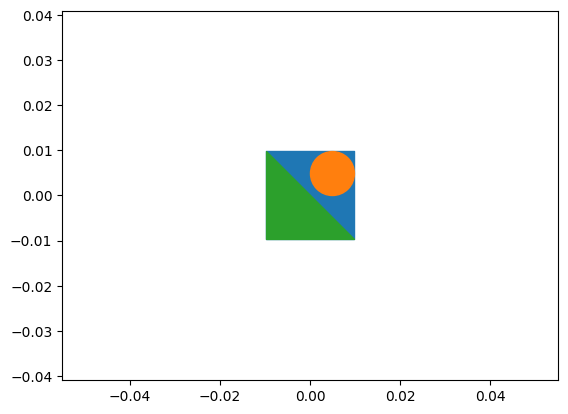

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(0,0, marker=markers[0], s=4000)
ax.scatter(0,0, marker=markers[1], s=4000)
ax.scatter(0.,0, marker=markers[2], s=4000)
ax.axis('equal')
plt.show()

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def fancy_line(x, y,
               jitter=0.02,
               wiggle=0.15,
               n_subdivide=8,
               cmap="viridis",
               lw=2):

    x = np.asarray(x)
    y = np.asarray(y)

    # --------------------------------------------------
    # 1. Subdivide line (more points = smoother squiggle)
    # --------------------------------------------------
    t = np.linspace(0, 1, len(x))
    t_new = np.linspace(0, 1, len(x) * n_subdivide)

    x_new = np.interp(t_new, t, x)
    y_new = np.interp(t_new, t, y)

    # --------------------------------------------------
    # 2. Add smooth "hand-drawn" wiggle (perpendicular noise)
    # --------------------------------------------------
    dx = np.gradient(x_new)
    dy = np.gradient(y_new)
    norm = np.sqrt(dx**2 + dy**2) + 1e-9

    # perpendicular vectors
    nx = -dy / norm
    ny = dx / norm

    noise = np.sin(np.linspace(0, 8*np.pi, len(x_new))) * wiggle
    noise += np.random.normal(scale=jitter, size=len(x_new))

    x_new = x_new + nx * noise
    y_new = y_new + ny * noise

    # --------------------------------------------------
    # 3. Build colored segments (gradient line)
    # --------------------------------------------------
    points = np.array([x_new, y_new]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    color_values = np.linspace(0, 1, len(segments))

    lc = LineCollection(segments, cmap=cmap, array=color_values,
                        linewidth=lw, capstyle="round")

    return lc

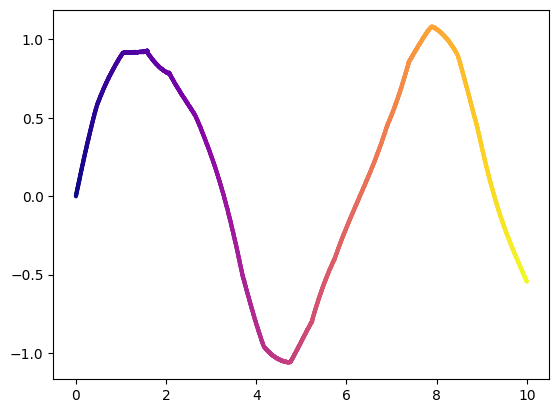

In [57]:
x = np.linspace(0, 10, 20)
y = np.sin(x)

fig, ax = plt.subplots()

line = fancy_line(x, y,
                  jitter=0.001,
                  wiggle=0.1,
                  cmap="plasma",
                  lw=3, n_subdivide=100)

ax.add_collection(line)
ax.autoscale()
ax.set_aspect("auto")

plt.show()